In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
import pandas as pd

df = pd.read_csv('/content/CVD_data.csv')
df

,No,Age,Gender,Height,Weight,SBP,DBP,Cholesterol,Glucose,Smoking,Alchol Intake,Physical Activity,Presence/Absence of CVD
0,64,60,1,175,59,140,100,2,1,1,0,1,0
1,1302,56,2,152,55,120,90,1,2,0,0,1,0
2,945,68,2,152,55,120,90,1,2,0,0,1,0
3,1079,49,1,182,81,155,115,3,2,1,0,1,1
4,129,46,2,183,61,120,80,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1775,1131,56,2,156,54,140,110,3,2,0,0,1,1
1776,1295,42,2,142,41,110,60,1,3,0,0,1,1
1777,861,61,1,165,65,100,60,1,1,0,0,0,0
1778,1460,45,2,157,56,130,100,1,3,0,0,0,0


In [4]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   No                       1780 non-null   int64 
 1   Age                      1780 non-null   int64 
 2   Gender                   1780 non-null   object
 3   Height                   1780 non-null   int64 
 4   Weight                   1780 non-null   int64 
 5   SBP                      1780 non-null   int64 
 6   DBP                      1780 non-null   int64 
 7   Cholesterol              1780 non-null   int64 
 8   Glucose                  1780 non-null   int64 
 9   Smoking                  1780 non-null   int64 
 10  Alchol Intake            1780 non-null   int64 
 11  Physical Activity        1780 non-null   int64 
 12  Presence/Absence of CVD  1780 non-null   int64 
dtypes: int64(12), object(1)
memory usage: 180.9+ KB


In [5]:

df['Presence/Absence of CVD'].value_counts()


,count
Presence/Absence of CVD,
0,1168
1,612


In [6]:

df['Gender'].value_counts()


,count
Gender,
1,904
2,874
M,1
F,1


In [7]:
df['Gender'] = df['Gender'].replace({'M': 1, 'F': 2})

df['Gender'].value_counts()

,count
Gender,
1,904
2,874
1,1
2,1


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

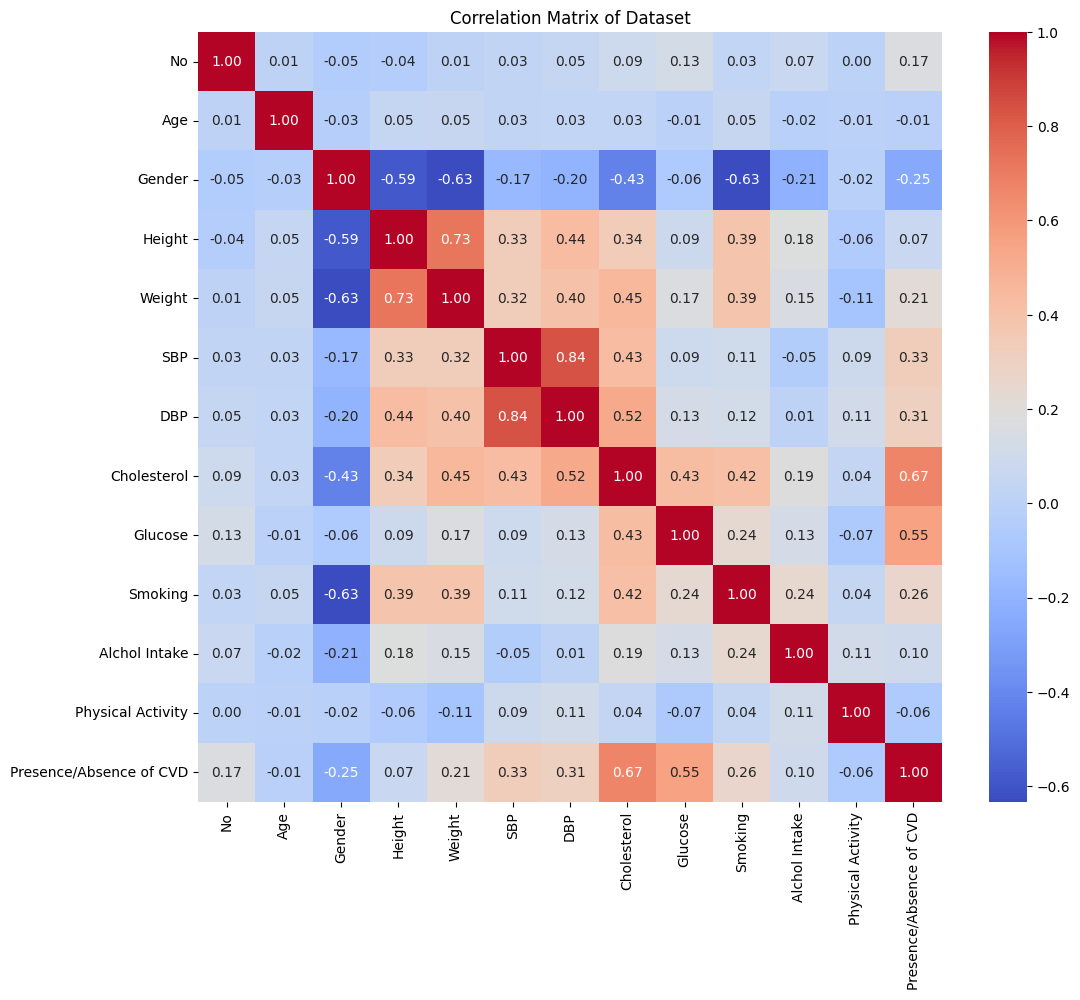

In [9]:

correlation_matrix = df.corr()

# Display the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Dataset')
plt.show()

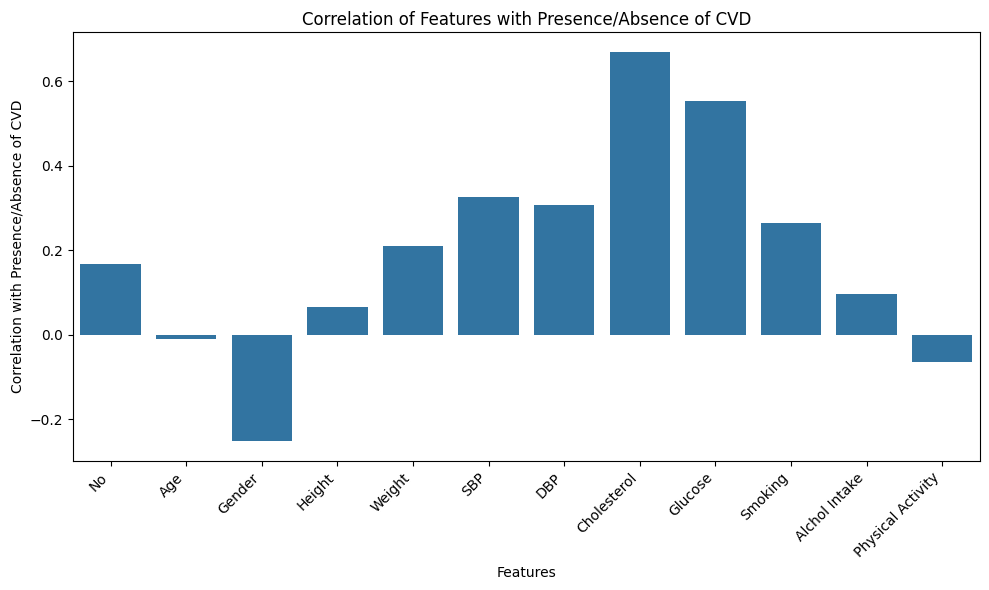

In [10]:

correlations = df.corr()['Presence/Absence of CVD'].drop('Presence/Absence of CVD')

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.index, y=correlations.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Correlation with Presence/Absence of CVD')
plt.title('Correlation of Features with Presence/Absence of CVD')
plt.tight_layout()
plt.show()

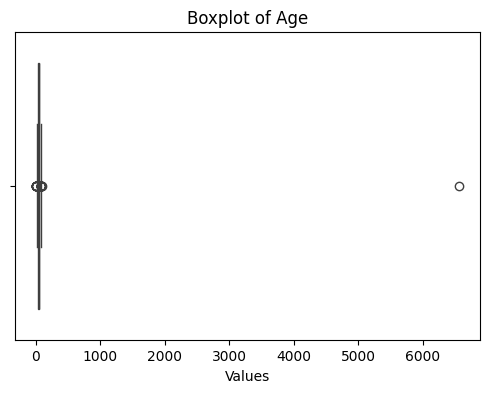

In [11]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Age'])
plt.title('Boxplot of Age')
plt.xlabel('Values')

plt.show()

In [12]:

top_5_ages = df['Age'].nlargest(5)

top_5_ages

,Age
85,6556
1476,96
833,92
970,91
1391,91


In [13]:

df = df[df['Age']<=120]

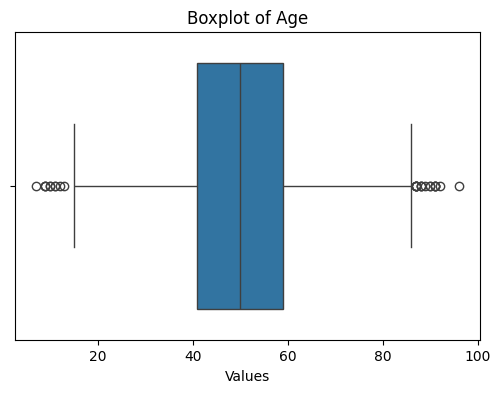

In [14]:

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Age'])
plt.title('Boxplot of Age')
plt.xlabel('Values')

plt.show()

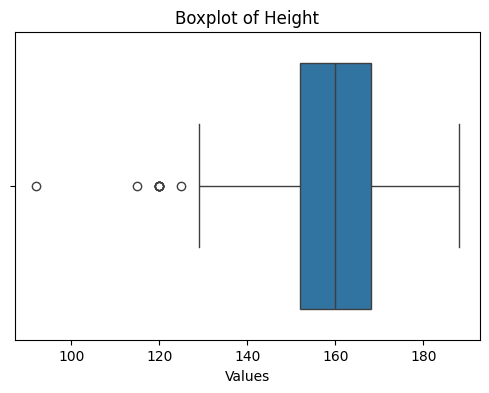

In [15]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Height'])
plt.title('Boxplot of Height')
plt.xlabel('Values')

plt.show()

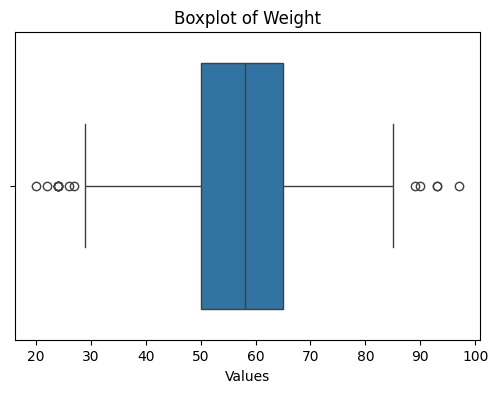

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Weight'])
plt.title('Boxplot of Weight')
plt.xlabel('Values')

plt.show()

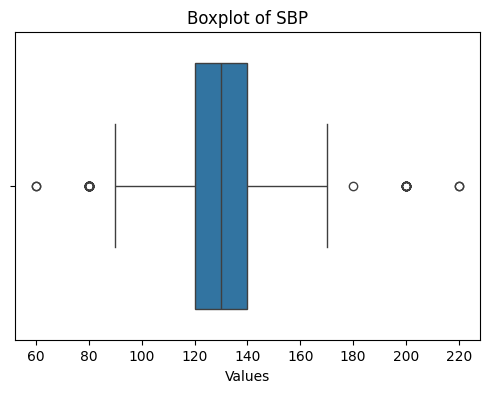

In [17]:

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['SBP'])
plt.title('Boxplot of SBP')
plt.xlabel('Values')

plt.show()

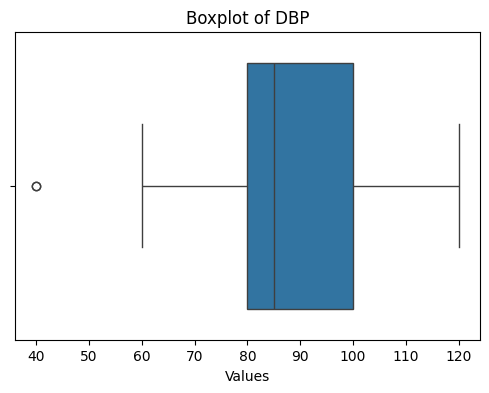

In [18]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['DBP'])
plt.title('Boxplot of DBP')
plt.xlabel('Values')

plt.show()

In [19]:

df['Cholesterol'].value_counts()

,count
Cholesterol,
1,1102
2,457
3,220


In [20]:

df['Glucose'].value_counts()

,count
Glucose,
1,906
2,567
3,306


In [21]:

df['Smoking'].value_counts()

,count
Smoking,
0,1258
1,521


In [22]:

df['Alchol Intake'].value_counts()

,count
Alchol Intake,
0,1700
1,79


In [23]:

df['Physical Activity'].value_counts()

,count
Physical Activity,
1,1371
0,408


In [24]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:

X = df.drop('Presence/Absence of CVD', axis=1)
y = df['Presence/Absence of CVD']

In [26]:

# prompt: code for oversampling the X and y using SMOTE both to increase both of the class to 300 more

from imblearn.over_sampling import SMOTE

# Assuming X and y are defined as in your previous code
# X = df.drop('Presence/Absence of CVD', axis=1)
# y = df['Presence/Absence of CVD']

smote = SMOTE(sampling_strategy={0: 6000, 1: 1000}) # oversample both classes to 300
X_resampled, y_resampled = smote.fit_resample(X, y)

In [27]:
X_resampled.shape

(7000, 12)

In [28]:

y_resampled

,Presence/Absence of CVD
0,0
1,0
2,0
3,1
4,0
...,...
6995,1
6996,1
6997,1
6998,1


In [29]:
y_resampled.value_counts()

,count
Presence/Absence of CVD,
0,6000
1,1000


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)



In [31]:
import numpy as np
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [32]:

rf_classifier = RandomForestClassifier(n_estimators=420, random_state=42)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(n_estimators=420, random_state=42)

In [33]:
y_pred = rf_classifier.predict(X_test)

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9928571428571429


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1203
           1       0.99      0.95      0.97       197

    accuracy                           0.99      1400
   macro avg       0.99      0.98      0.98      1400
weighted avg       0.99      0.99      0.99      1400



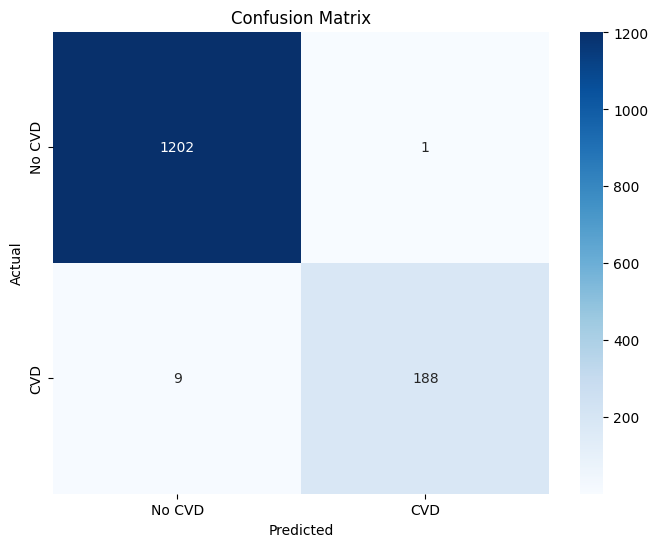

In [36]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CVD', 'CVD'], yticklabels=['No CVD', 'CVD'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [37]:
pip install shap


Shape of SHAP values for CVD presence (class 1): (1400, 12)
Shape of X_test: (1400, 12)


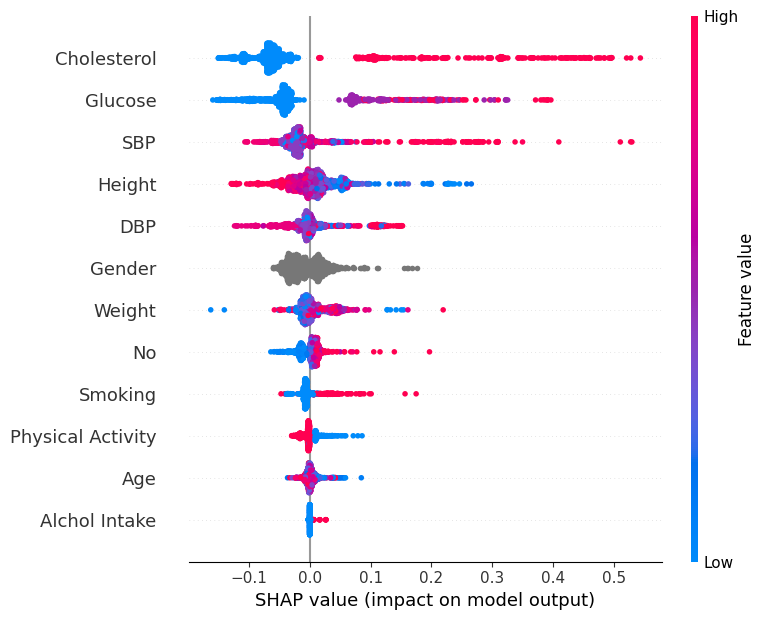

In [54]:
import shap

# Assuming rf_model is already trained and shap_values is computed
# ... (previous code) ...

# Correctly extract SHAP values for the positive class (CVD presence, class 1)
# The second axis (index 1) in shap_values corresponds to the output class.
shap_values_positive_class = shap_values[:, :, 1]

# Ensure the shape of shap_values for CVD presence (class 1) is (1400, 12)
print(f"Shape of SHAP values for CVD presence (class 1): {shap_values_positive_class.shape}")
print(f"Shape of X_test: {X_test.shape}")

# Check if shapes match
assert shap_values_positive_class.shape[0] == X_test.shape[0]  # number of samples match
assert shap_values_positive_class.shape[1] == X_test.shape[1]  # number of features match

# Summary plot for feature importance (2D)
shap.summary_plot(shap_values_positive_class, X_test)  # For positive class CVD presence







In [58]:
!pip install lime




In [61]:
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd # Import pandas

# Convert X_train back to DataFrame for LIME:
#X_train_df = pd.DataFrame(X_train, columns=X.columns) # This line is redundant as X_train is already a DataFrame
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,  # Pass the DataFrame values as a NumPy array
    training_labels=y_train,  # Training labels
    mode="classification",  # This is a classification task
    feature_names=X_train.columns,  # Feature names (column names from the DataFrame)
    class_names=["CVD Absence", "CVD Presence"],  # Class names (binary classes)
    discretize_continuous=True  # Discretize continuous features for explanation
)

# Choose a random sample from the test set to explain
idx = 10  # Choose an index for a specific prediction from the test set
# Convert X_test to DataFrame for sample selection:
# X_test_df = pd.DataFrame(X_test, columns=X.columns) # This line is redundant as X_test is already a DataFrame
sample_to_explain = X_test.iloc[idx]

# Explain the prediction for the chosen sample
# Assuming rf_classifier is your trained model
explanation = explainer.explain_instance(
    sample_to_explain.values,  # The specific instance to explain
    rf_classifier.predict_proba,    # Predict probability function from the Random Forest model
    num_features=10            # Show top 10 most important features
)

# Show the explanation in a human-readable format
explanation.show_in_notebook()  # This will render an explanation plot in the notebook

# Alternatively, you can print the explanation as a list of features and their contributions:
print(explanation.as_list())





[('Cholesterol > 1.00', 0.3602770676936127), ('Glucose > 2.00', 0.14735595877885627), ('Height <= 152.00', 0.08701666843682314), ('1.88 < Gender <= 2.00', -0.06645059173735487), ('Alchol Intake <= 0.00', -0.05907194141844042), ('120.00 < SBP <= 135.00', -0.05389707562953173), ('No <= 189.75', -0.052774360934918337), ('Smoking > 0.00', 0.0457475575039569), ('0.00 < Physical Activity <= 1.00', -0.023203691021022196), ('54.00 < Weight <= 63.00', -0.010088486008973312)]
